# CPU Scheduling — Choosing What Runs Next

When several processes compete for one CPU, a **scheduling algorithm** decides their order. The choice trades off **throughput**, **average waiting time**, **response time**, and **fairness**. We measure each process by its **arrival time** and **burst time** (CPU time needed) and evaluate a schedule by completion, turnaround ($=$ completion $-$ arrival), and waiting ($=$ turnaround $-$ burst). Each algorithm builds its **Gantt chart** one time-slice at a time so the dispatch decisions can be watched and the metrics compared.

$$ \text{turnaround}_i = C_i - A_i, \qquad \text{waiting}_i = \text{turnaround}_i - B_i, \qquad \overline{W} = \frac1n\sum_i \text{waiting}_i. $$

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def make_player(n_steps, render, label='time'):
    slider = widgets.IntSlider(value=0, min=0, max=n_steps-1, description=label,
                               continuous_update=False, layout=widgets.Layout(width='60%'))
    play = widgets.Play(value=0, min=0, max=n_steps-1, interval=500)
    widgets.jslink((play, 'value'), (slider, 'value'))
    out = widgets.interactive_output(render, {'k': slider})
    display(widgets.HBox([play, slider]), out)

# Workload: pid -> (arrival, burst, priority). Lower priority number = higher priority.
JOBS = {
    'P1': dict(arrival=0, burst=7, prio=2),
    'P2': dict(arrival=2, burst=4, prio=1),
    'P3': dict(arrival=4, burst=1, prio=3),
    'P4': dict(arrival=5, burst=4, prio=2),
}
PIDS = list(JOBS)
COLORS = {'P1':'#7eb0d5', 'P2':'#fd7f6f', 'P3':'#b2e061', 'P4':'#ffb55a', 'idle':'#e8e8e8'}

# A 'timeline' is a list of length T, each entry a pid (or 'idle') running in slot [t, t+1).
def draw_gantt(timeline, upto, jobs, title='', extra=''):
    T = len(timeline)
    fig, ax = plt.subplots(figsize=(10, 2.8))
    for t in range(T):
        pid = timeline[t]
        filled = t < upto
        c = COLORS[pid] if filled else 'white'
        ax.add_patch(plt.Rectangle((t, 0), 1, 1, facecolor=c,
                     edgecolor='k' if filled else 'lightgray', lw=1))
        if filled and pid != 'idle':
            ax.text(t+0.5, 0.5, pid, ha='center', va='center', fontsize=9)
        elif filled:
            ax.text(t+0.5, 0.5, '-', ha='center', va='center', fontsize=9, color='gray')
    # arrival markers
    for pid in jobs:
        a = jobs[pid]['arrival']
        ax.annotate(pid+'\\n arr', xy=(a, 1.05), ha='center', va='bottom', fontsize=7,
                    color=COLORS[pid])
    for t in range(T+1):
        ax.text(t, -0.25, str(t), ha='center', va='top', fontsize=8, color='gray')
    ax.axvline(upto, color='tomato', lw=2)
    ax.set_xlim(0, T); ax.set_ylim(-0.5, 1.6)
    ax.set_title(title); ax.text(0.0, -0.55, extra, transform=ax.transAxes, fontsize=10,
                                 color='dimgray', va='top')
    ax.axis('off'); plt.show()

def metrics(timeline, jobs):
    # completion time = last slot+1 where each pid runs
    comp = {}
    for t, pid in enumerate(timeline):
        if pid != 'idle': comp[pid] = t+1
    rows = {}
    for pid in jobs:
        A, B = jobs[pid]['arrival'], jobs[pid]['burst']
        C = comp.get(pid, A)
        ta = C - A; wt = ta - B
        rows[pid] = (C, ta, wt)
    avg_wt = np.mean([rows[p][2] for p in jobs])
    avg_ta = np.mean([rows[p][1] for p in jobs])
    return rows, avg_wt, avg_ta

def metrics_text(timeline, jobs, upto_done=True):
    rows, awt, ata = metrics(timeline, jobs)
    line = '  '.join(f'{p}: W={rows[p][2]} TA={rows[p][1]}' for p in jobs)
    return f'{line}   |   avg wait = {awt:.2f}, avg turnaround = {ata:.2f}'

## The Shared Workload

Every algorithm below schedules the same four processes, so the only difference in the resulting Gantt charts and metrics is the policy itself. The table fixes arrival, burst, and priority; the bars preview each job's CPU demand.

$$ \text{compare policies on identical } (A_i, B_i, \text{prio}_i). $$

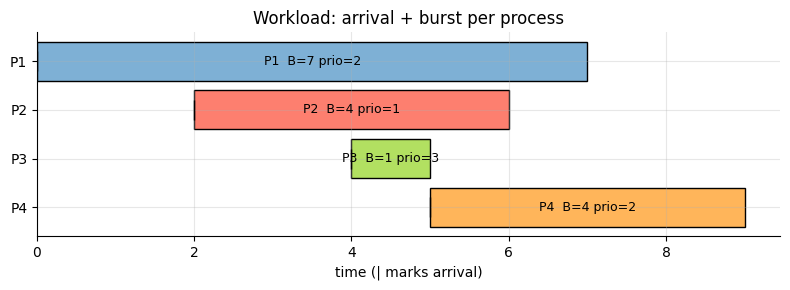

In [2]:
fig, ax = plt.subplots(figsize=(8, 3))
y = np.arange(len(PIDS))[::-1]
for i, pid in enumerate(PIDS):
    j = JOBS[pid]
    ax.barh(y[i], j['burst'], left=j['arrival'], color=COLORS[pid], edgecolor='k')
    ax.text(j['arrival']+j['burst']/2, y[i], f"{pid}  B={j['burst']} prio={j['prio']}",
            ha='center', va='center', fontsize=9)
    ax.plot(j['arrival'], y[i], 'k|', ms=14)
ax.set_yticks(y); ax.set_yticklabels(PIDS)
ax.set_xlabel('time (| marks arrival)'); ax.set_title('Workload: arrival + burst per process')
plt.tight_layout(); plt.show()

## First-Come First-Served — Run in Arrival Order

FCFS dispatches processes in the order they arrive and runs each to completion (**non-preemptive**). Simple and fair in ordering, but a long job arriving first delays everyone behind it — the **convoy effect**. Step through to watch the chart fill strictly by arrival and the average wait accumulate.

$$ \text{order} = \text{sort by } A_i; \quad \text{run each fully before the next.} $$

In [3]:
def fcfs_timeline(jobs):
    order = sorted(jobs, key=lambda p: (jobs[p]['arrival'], p))
    timeline = []; t = 0
    for pid in order:
        a = jobs[pid]['arrival']
        while t < a:
            timeline.append('idle'); t += 1
        for _ in range(jobs[pid]['burst']):
            timeline.append(pid); t += 1
    return timeline

tl = fcfs_timeline(JOBS)
def draw_fcfs(k):
    draw_gantt(tl, k, JOBS, title=f'FCFS  (t = {k}/{len(tl)})',
               extra=metrics_text(tl, JOBS) if k==len(tl) else f'CPU running: {tl[k-1] if k>0 else "-"}')
make_player(len(tl)+1, draw_fcfs)

Output()

## Shortest Job First — Pick the Smallest Burst

SJF (non-preemptive) selects, among processes that have **arrived**, the one with the smallest burst. It provably **minimizes average waiting time** but can **starve** long jobs and requires knowing burst lengths in advance. Watch how it reorders relative to FCFS to let short jobs slip ahead.

$$ \text{at each dispatch: choose } \arg\min_i \{B_i : A_i \le t\}. $$

In [4]:
def sjf_timeline(jobs):
    remaining = set(jobs); timeline = []; t = 0
    while remaining:
        ready = [p for p in remaining if jobs[p]['arrival'] <= t]
        if not ready:
            timeline.append('idle'); t += 1; continue
        pid = min(ready, key=lambda p: (jobs[p]['burst'], jobs[p]['arrival'], p))
        for _ in range(jobs[pid]['burst']):
            timeline.append(pid); t += 1
        remaining.discard(pid)
    return timeline

tl = sjf_timeline(JOBS)
def draw_sjf(k):
    draw_gantt(tl, k, JOBS, title=f'SJF (non-preemptive)  (t = {k}/{len(tl)})',
               extra=metrics_text(tl, JOBS) if k==len(tl) else f'CPU running: {tl[k-1] if k>0 else "-"}')
make_player(len(tl)+1, draw_sjf)

Output()

## Priority Scheduling — Highest Priority Runs

Each process carries a **priority**; the scheduler dispatches the ready process with the best (here, numerically smallest) priority. Like SJF it risks **starvation** of low-priority jobs, classically mitigated by **aging** (gradually raising the priority of waiting jobs). This version is non-preemptive. Watch dispatch follow priority rather than arrival or burst.

$$ \text{at each dispatch: choose } \arg\min_i \{\text{prio}_i : A_i \le t\}. $$

In [5]:
def priority_timeline(jobs):
    remaining = set(jobs); timeline = []; t = 0
    while remaining:
        ready = [p for p in remaining if jobs[p]['arrival'] <= t]
        if not ready:
            timeline.append('idle'); t += 1; continue
        pid = min(ready, key=lambda p: (jobs[p]['prio'], jobs[p]['arrival'], p))
        for _ in range(jobs[pid]['burst']):
            timeline.append(pid); t += 1
        remaining.discard(pid)
    return timeline

tl = priority_timeline(JOBS)
def draw_prio(k):
    draw_gantt(tl, k, JOBS, title=f'Priority (lower number = higher)  (t = {k}/{len(tl)})',
               extra=metrics_text(tl, JOBS) if k==len(tl) else f'CPU running: {tl[k-1] if k>0 else "-"}')
make_player(len(tl)+1, draw_prio)

Output()

## Round Robin — Time-Sliced Fairness

Round Robin is **preemptive**: each ready process runs for at most one **quantum** $q$, then is sent to the back of the ready queue. Small $q$ improves responsiveness but adds context-switch overhead; large $q$ degenerates toward FCFS. Adjust the quantum and watch the chart fragment or coalesce, and the average wait shift.

$$ q \to \infty \Rightarrow \text{FCFS}; \qquad q \to 1 \Rightarrow \text{maximal time-sharing.} $$

In [6]:
from collections import deque

def rr_timeline(jobs, q):
    rem = {p: jobs[p]['burst'] for p in jobs}
    timeline = []; t = 0; ready = deque()
    arrivals = sorted(jobs, key=lambda p: jobs[p]['arrival'])
    pending = list(arrivals)
    def admit(up_to):
        i = 0
        while i < len(pending):
            p = pending[i]
            if jobs[p]['arrival'] <= up_to:
                ready.append(p); pending.pop(i)
            else:
                i += 1
    admit(0)
    while ready or pending:
        if not ready:
            timeline.append('idle'); t += 1; admit(t); continue
        pid = ready.popleft()
        run = min(q, rem[pid])
        for _ in range(run):
            timeline.append(pid); t += 1; admit(t)
        rem[pid] -= run
        if rem[pid] > 0:
            ready.append(pid)        # back of queue
    return timeline

q_s = widgets.IntSlider(value=2, min=1, max=7, description='quantum q')
rr_area = widgets.Output()
def relaunch_rr(*_):
    tl = rr_timeline(JOBS, q_s.value)
    def draw(k):
        draw_gantt(tl, k, JOBS, title=f'Round Robin (q={q_s.value})  (t = {k}/{len(tl)})',
                   extra=metrics_text(tl, JOBS) if k==len(tl) else f'CPU running: {tl[k-1] if k>0 else "-"}')
    rr_area.clear_output(wait=True)
    with rr_area: make_player(len(tl)+1, draw)
q_s.observe(relaunch_rr, 'value')
display(q_s, rr_area)
relaunch_rr()

IntSlider(value=2, description='quantum q', max=7, min=1)

Output()

## Side-by-Side: Average Waiting Time

Holding the workload fixed, the policies produce different average waiting times. SJF is optimal for this metric among non-preemptive policies; FCFS suffers the convoy effect; Round Robin's wait depends on the quantum. The chart computes each policy's average wait on the shared workload (Round Robin shown across several quanta).

$$ \overline{W}_{\text{SJF}} \le \overline{W}_{\text{any non-preemptive policy}}. $$

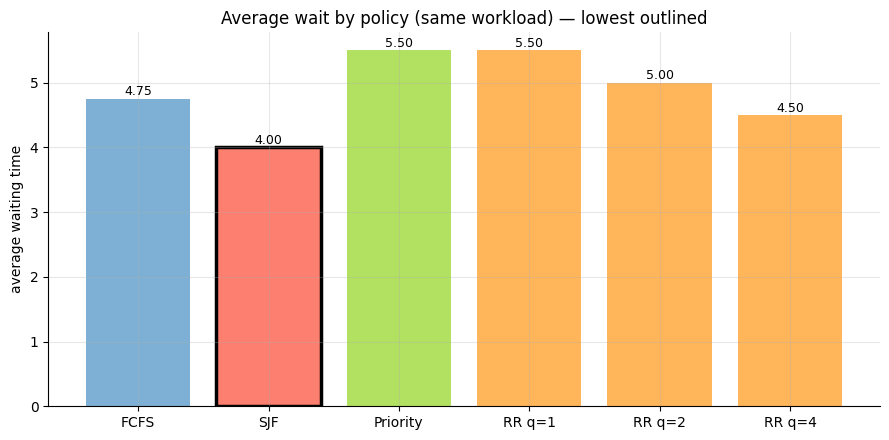

In [7]:
policies = {
    'FCFS': fcfs_timeline(JOBS),
    'SJF': sjf_timeline(JOBS),
    'Priority': priority_timeline(JOBS),
    'RR q=1': rr_timeline(JOBS, 1),
    'RR q=2': rr_timeline(JOBS, 2),
    'RR q=4': rr_timeline(JOBS, 4),
}
names = list(policies); waits = [metrics(policies[n], JOBS)[1] for n in names]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(names, waits, color=['#7eb0d5','#fd7f6f','#b2e061','#ffb55a','#ffb55a','#ffb55a'])
best = int(np.argmin(waits)); bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.5)
for b, w in zip(bars, waits):
    ax.text(b.get_x()+b.get_width()/2, w+0.05, f'{w:.2f}', ha='center', fontsize=9)
ax.set_ylabel('average waiting time')
ax.set_title('Average wait by policy (same workload) — lowest outlined')
plt.tight_layout(); plt.show()